# Mineração de Processos — Geofencing SMS Campaign
**Processo**: Ciclo de vida de envio de SMS via Twilio (campanha geofencing_sms)
**Período**: Ago/2022 – Ago/2025 | **Log**: Original (LO)
**Questões de pesquisa**:
1. Qual é o fluxo real do processo de envio de SMS?
2. Qual a taxa de entrega e como ela varia ao longo do tempo?
3. Existe sazonalidade (hora, dia da semana) no volume de envios?
4. Quais são os principais gargalos ou desvios do caminho feliz?

In [ ]:
!pip install pm4py
!wget https://raw.githubusercontent.com/abraaorochapb/trabalho_final_process_mining/main/event_log.csv

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pm4py as pm
from pm4py.visualization.dfg import visualizer
from collections import Counter

sns.set_theme(style="whitegrid")

In [2]:
CAMPANHAS_TESTE = [
    "my_test_campaign_next",
    "test_campaign_for_adam_onsite",
    "test_campaign_for_argparse_flag",
    "onsite_joe_p_greenfield_test",
    "campaign_deployment_test",
    "alex_manual_test",
    "new_retail_conversion",
]

df_raw = pd.read_csv("event_log.csv")
print(f"Log completo: {len(df_raw)} eventos, {df_raw['case_id'].nunique()} casos")
print(f"Campanhas encontradas: {df_raw['campaign_name'].unique()}")

df = df_raw[~df_raw["campaign_name"].isin(CAMPANHAS_TESTE)].dropna(subset=["campaign_name"]).copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"\nApós filtro (geofencing_sms): {len(df)} eventos, {df['case_id'].nunique()} casos")
print(f"Período: {df['timestamp'].min()} a {df['timestamp'].max()}")
df.info()

Log completo: 95891 eventos, 48647 casos
Campanhas encontradas: <StringArray>
[          'my_test_campaign_next',   'test_campaign_for_adam_onsite',
 'test_campaign_for_argparse_flag',                               nan,
                  'geofencing_sms',    'onsite_joe_p_greenfield_test',
                'alex_manual_test',        'campaign_deployment_test',
           'new_retail_conversion']
Length: 9, dtype: str

Após filtro (geofencing_sms): 94283 eventos, 47476 casos
Período: 2022-08-19 12:53:34 a 2025-08-29 00:37:40
<class 'pandas.DataFrame'>
Index: 94283 entries, 50 to 95890
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   case_id        94283 non-null  str           
 1   activity       94283 non-null  str           
 2   timestamp      94283 non-null  datetime64[us]
 3   campaign_name  94283 non-null  str           
 4   from           94283 non-null  int64         
 5   to             9

In [3]:
print("\n=== Distribuição de atividades ===")
print(df["activity"].value_counts())

print("\n=== Traces mais comuns ===")
traces = Counter()
for case, grp in df.groupby("case_id"):
    acts = tuple(grp.sort_values("timestamp")["activity"])
    traces[acts] += 1
for t, n in traces.most_common(10):
    print(f"  {' → '.join(t)}: {n} casos ({n/df['case_id'].nunique()*100:.1f}%)")


=== Distribuição de atividades ===
activity
sent           46857
delivered      45342
undelivered     2082
failed             2
Name: count, dtype: int64

=== Traces mais comuns ===
  sent → delivered: 45317 casos (95.5%)
  sent → undelivered: 1452 casos (3.1%)
  undelivered: 624 casos (1.3%)
  sent: 63 casos (0.1%)
  sent → sent → delivered → delivered: 7 casos (0.0%)
  sent → delivered → delivered: 3 casos (0.0%)
  delivered: 2 casos (0.0%)
  failed: 2 casos (0.0%)
  sent → sent → delivered: 2 casos (0.0%)
  delivered → sent: 1 casos (0.0%)


In [4]:
total_sent    = df[df["activity"] == "sent"]["case_id"].nunique()
total_del     = df[df["activity"] == "delivered"]["case_id"].nunique()
total_undel   = df[df["activity"] == "undelivered"]["case_id"].nunique()

tx_entrega   = total_del / (total_del + total_undel) * 100
print(f"\nCasos com 'sent':       {total_sent}")
print(f"Casos com 'delivered':  {total_del}")
print(f"Casos com 'undelivered':{total_undel}")
print(f"Taxa de entrega: {tx_entrega:.2f}%")


Casos com 'sent':       46847
Casos com 'delivered':  45332
Casos com 'undelivered':2079
Taxa de entrega: 95.61%


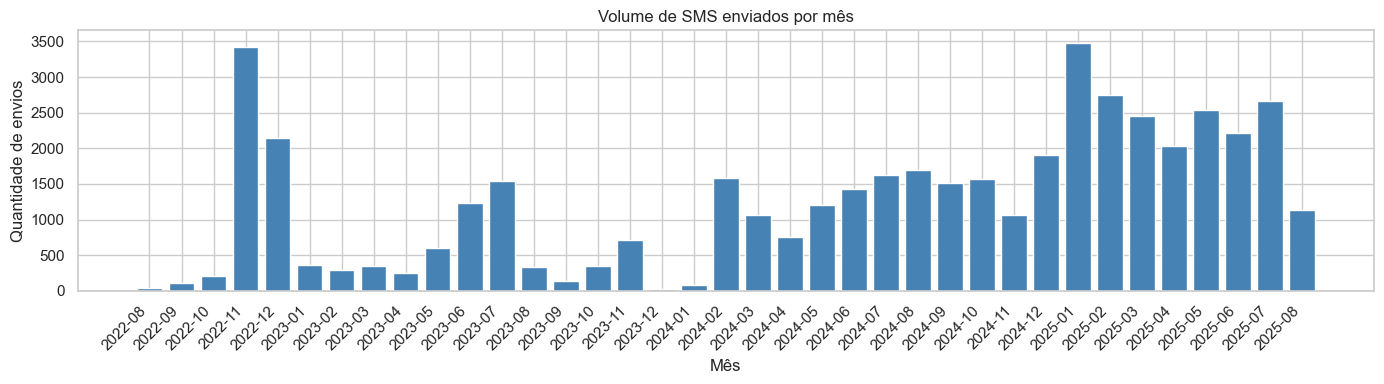

Salvo: grafico_volume_mensal.png


In [5]:
df_sent = df[df["activity"] == "sent"].copy()
df_sent["mes"] = df_sent["timestamp"].dt.to_period("M")
vol_mensal = df_sent.groupby("mes").size().reset_index(name="envios")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vol_mensal["mes"].astype(str), vol_mensal["envios"], color="steelblue")
ax.set_title("Volume de SMS enviados por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade de envios")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("grafico_volume_mensal.png", dpi=150)
plt.show()
print("Salvo: grafico_volume_mensal.png")

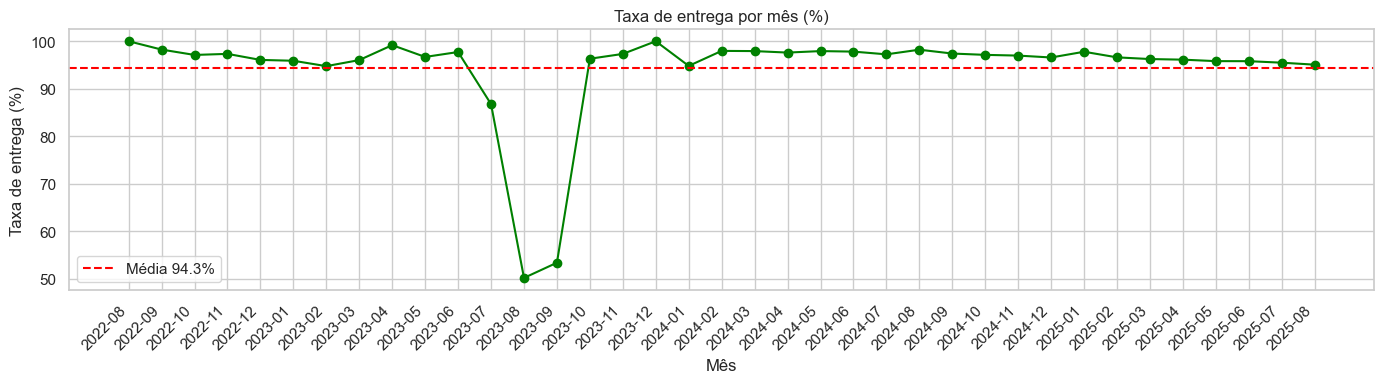

Salvo: grafico_taxa_entrega_mensal.png


In [6]:
df_mes = df[df["activity"].isin(["sent", "delivered", "undelivered"])].copy()
df_mes["mes"] = df_mes["timestamp"].dt.to_period("M")
pivot = df_mes.groupby(["mes", "activity"]).size().unstack(fill_value=0).reset_index()
pivot = pivot.reindex(columns=["mes", "sent", "delivered", "undelivered"], fill_value=0)
pivot["taxa_entrega"] = pivot["delivered"] / (pivot["delivered"] + pivot["undelivered"]) * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pivot["mes"].astype(str), pivot["taxa_entrega"], marker="o", color="green")
ax.axhline(pivot["taxa_entrega"].mean(), color="red", linestyle="--", label=f"Média {pivot['taxa_entrega'].mean():.1f}%")
ax.set_title("Taxa de entrega por mês (%)")
ax.set_xlabel("Mês")
ax.set_ylabel("Taxa de entrega (%)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("grafico_taxa_entrega_mensal.png", dpi=150)
plt.show()
print("Salvo: grafico_taxa_entrega_mensal.png")

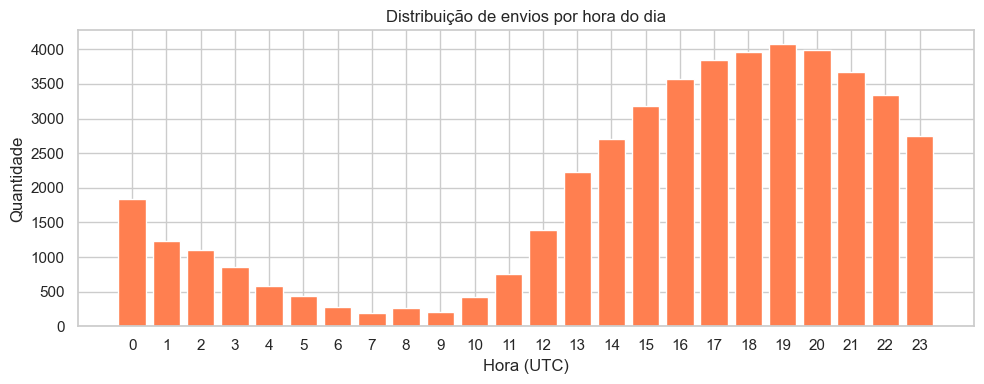

Salvo: grafico_hora_envio.png


In [7]:
df_sent["hora"] = df_sent["timestamp"].dt.hour
hora_counts = df_sent.groupby("hora").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hora_counts.index, hora_counts.values, color="coral")
ax.set_title("Distribuição de envios por hora do dia")
ax.set_xlabel("Hora (UTC)")
ax.set_ylabel("Quantidade")
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig("grafico_hora_envio.png", dpi=150)
plt.show()
print("Salvo: grafico_hora_envio.png")

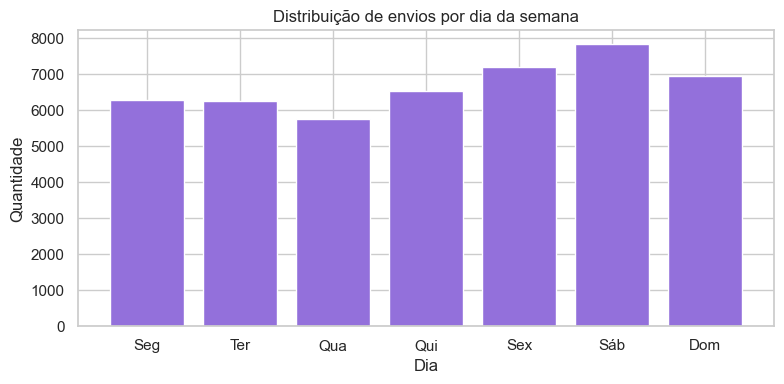

Salvo: grafico_dia_semana.png


In [8]:
DIAS = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
df_sent["dia_semana"] = df_sent["timestamp"].dt.dayofweek
dia_counts = df_sent.groupby("dia_semana").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([DIAS[i] for i in dia_counts.index], dia_counts.values, color="mediumpurple")
ax.set_title("Distribuição de envios por dia da semana")
ax.set_xlabel("Dia")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig("grafico_dia_semana.png", dpi=150)
plt.show()
print("Salvo: grafico_dia_semana.png")


Total de respostas recebidas: 713
Taxa de resposta (received / sent): 1.52%


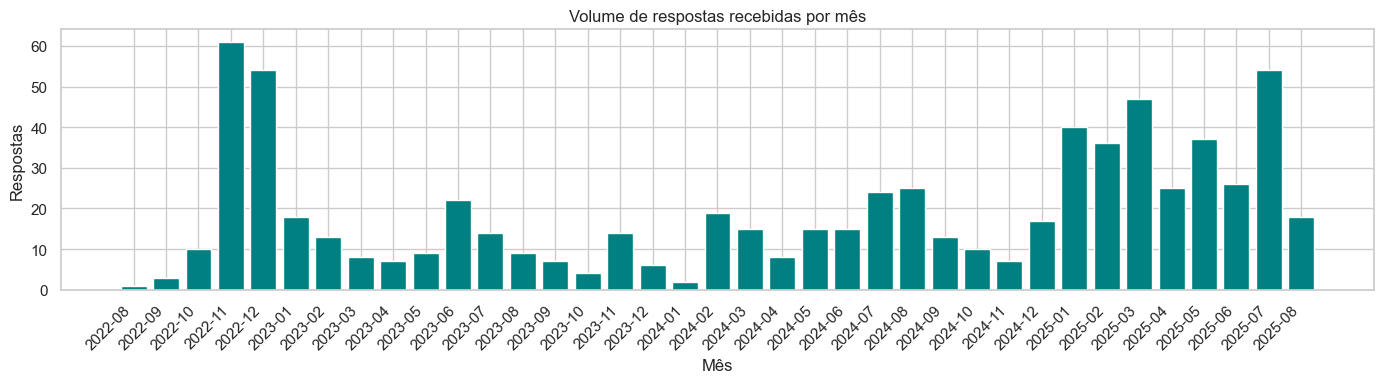

Salvo: grafico_respostas_mensal.png


In [9]:
resp = df_raw[df_raw["activity"] == "received"].copy()
print(f"\nTotal de respostas recebidas: {len(resp)}")
print(f"Taxa de resposta (received / sent): {len(resp)/total_sent*100:.2f}%")

resp["timestamp"] = pd.to_datetime(resp["timestamp"])
resp["mes"] = resp["timestamp"].dt.to_period("M")
resp_mensal = resp.groupby("mes").size().reset_index(name="respostas")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(resp_mensal["mes"].astype(str), resp_mensal["respostas"], color="teal")
ax.set_title("Volume de respostas recebidas por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Respostas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("grafico_respostas_mensal.png", dpi=150)
plt.show()
print("Salvo: grafico_respostas_mensal.png")

In [10]:
df_formated = df.rename(columns={
    "case_id":   "case:concept:name",
    "activity":  "concept:name",
    "timestamp": "time:timestamp",
})
print(df_formated[["case:concept:name", "concept:name", "time:timestamp"]].head())

                     case:concept:name concept:name      time:timestamp
50  SM128abf8e3ab1ec859132c276e61bf916         sent 2022-08-19 12:53:34
51  SM128abf8e3ab1ec859132c276e61bf916    delivered 2022-08-19 12:53:34
52  SM2952d38dfcaf61844c41dd379710939b         sent 2022-08-19 22:09:36
53  SM2952d38dfcaf61844c41dd379710939b    delivered 2022-08-19 22:09:36
54  SM21030b44259a815a99a55b86fc1046af         sent 2022-08-19 22:24:02


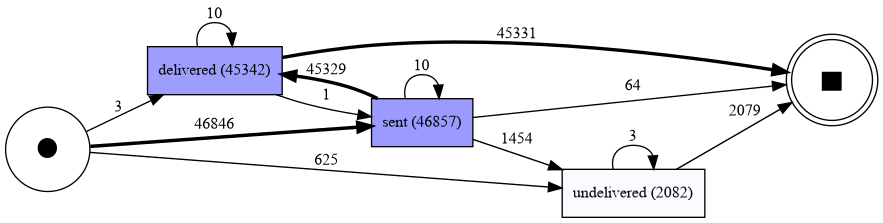

DFG salvo: dfg_geofencing.png


In [11]:
dfg, sa, ea = pm.discover_directly_follows_graph(df_formated)

# Remove "failed" (atividade isolada — 2 casos) para evitar bug pm4py
sa_clean = {k: v for k, v in sa.items() if k != "failed"}
ea_clean = {k: v for k, v in ea.items() if k != "failed"}

parameters = {
    visualizer.Variants.FREQUENCY.value.Parameters.START_ACTIVITIES: sa_clean,
    visualizer.Variants.FREQUENCY.value.Parameters.END_ACTIVITIES:   ea_clean,
}
activities_count = df_formated["concept:name"].value_counts().to_dict()

viz = visualizer.apply(dfg, log=df_formated, activities_count=activities_count, parameters=parameters)
visualizer.save(viz, "dfg_geofencing.png")
visualizer.view(viz)
print("DFG salvo: dfg_geofencing.png")

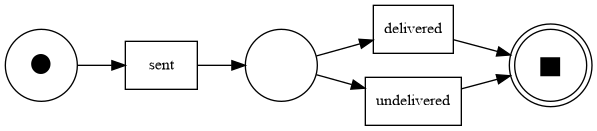

Petri net Alpha salva: petri_net_alpha.png


In [12]:
# Filtra apenas as variantes normais para descoberta (98.6% dos casos).
# Casos anômalos (undelivered sem sent, duplicatas, failed) são ruído e distorcem o modelo.
# A conformidade (seção 14) é feita no log completo
_traces = df_formated.groupby("case:concept:name").apply(
    lambda g: tuple(g.sort_values("time:timestamp")["concept:name"])
)
_casos_normais = _traces[_traces.isin([("sent", "delivered"), ("sent", "undelivered")])].index
df_discovery = df_formated[df_formated["case:concept:name"].isin(_casos_normais)]

net_alpha, im_alpha, fm_alpha = pm.discover_petri_net_alpha(df_discovery)
pm.save_vis_petri_net(net_alpha, im_alpha, fm_alpha, "petri_net_alpha.png")
pm.view_petri_net(net_alpha, im_alpha, fm_alpha)
print("Petri net Alpha salva: petri_net_alpha.png")

In [13]:
# Token-based replay mede quantos tokens "faltam" ou "sobram" ao reproduzir o log no modelo
fitness = pm.fitness_token_based_replay(df_formated, net_alpha, im_alpha, fm_alpha)
print("\n=== Fitness (Token Replay — Alpha Miner) ===")
for k, v in fitness.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

replaying log with TBR, completed traces :: 100%|██████████| 13/13 [00:00<00:00, 13.92it/s]


=== Fitness (Token Replay — Alpha Miner) ===
  perc_fit_traces: 98.5108
  average_trace_fitness: 0.9926
  log_fitness: 0.9950
  percentage_of_fitting_traces: 98.5108
